# Week 2 In-Class Assessment

*Work through the following notebook and then complete the Week 2 In-Class Assessment Quercus Quiz on the course website.*

## Summary Statistics using [UTSC Weather Station Data](https://weather.utsc.utoronto.ca/data/)

We are going to take a look at calculating summary statistics using the hourly surface pressure data from the UTSC weather station from 2015-2022.

First, we import the packages that we will need:

In [2]:
#  import packages
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rc('font',size=16) #set default font size and weight for plots

Next, we load the hourly UTSC Weather Station surface pressure data from 2015-2022

In [3]:
#  load data 
#  UTSC surface pressure data for the years 2015-2022 in kPa. 
#  Data are collected hourly.
filename = 'UTSC_P_20152022.csv'
PS = np.genfromtxt(filename, delimiter = ',')

## I. Preliminary Data Visualization

One of the first things we should always do when analyzing a data set is to first take a look at the raw data.

Let's plot the hourly surface pressure as we did in the temperature example in lecture:

In [4]:
#  as we did in the courseware, we create the time dimension data in units of days for plotting
ps_index = (np.arange(0,np.size(PS),1))/24.0

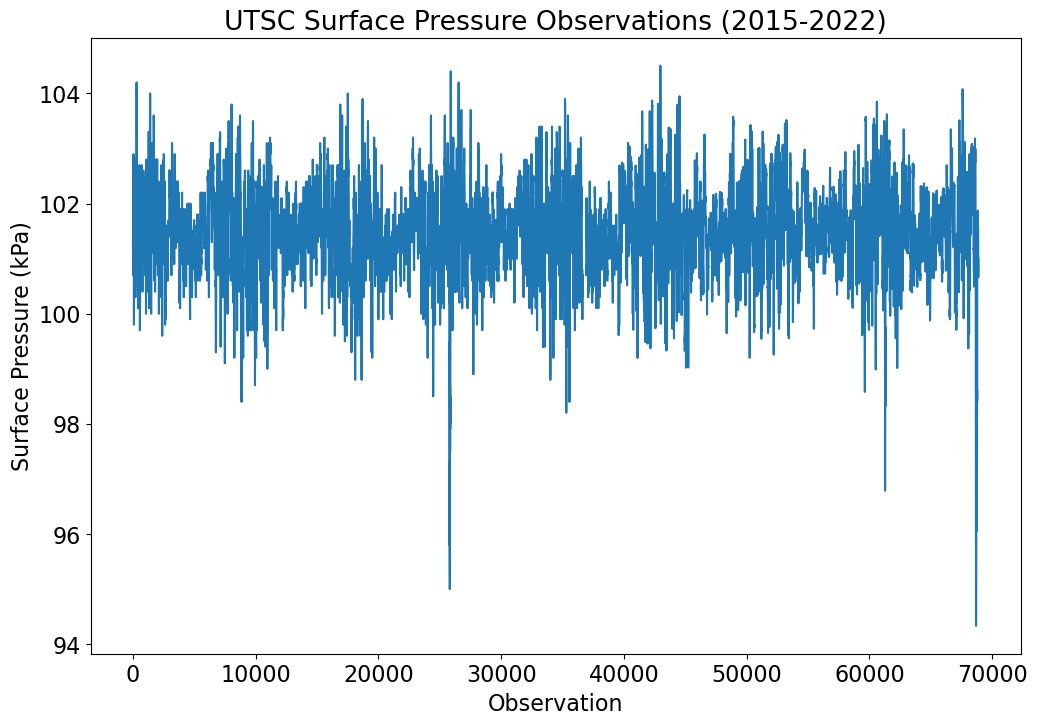

In [9]:
#  plot all data
fig = plt.figure(figsize=(12,8))

#fill in the line below
plt.plot(ps_index, PS)

plt.ylabel('Surface Pressure (kPa)')
plt.xlabel('Observation')
plt.title("UTSC Surface Pressure Observations (2015-2022)")
plt.savefig('Fig1.png')

## II. Summary Statistics

Recall, from lecture 1 and the videos, that there are several useful summary statistics.

- the mean
- the median
- the maximum & minimum (or the range)
- the 25th and 75th quartiles

Let's calculate these statistics for surface pressure.

In [5]:
#  Mean surface pressure (use the np.mean() function)

avg_PS = np.mean(PS)
print(avg_PS)

nan


Uh-oh! This likely means that we have some missing values. Let's just remove them for now.

In [6]:
#  Remove missing values
#  The ~ symbol is equivalent to "invert". It's sort of (but not exactly) like "not. 
#  So, this line says, extract the values from PS that are not nan's
PS = PS[~np.isnan(PS)]

Now, let's try computing the mean again.

In [7]:
#  Mean surface pressure (use the np.mean() function)

avg_PS = np.mean(PS)
print(avg_PS)

101.5533818908496


Note that the *alternative* python syntax looks like this:

In [8]:
#  alternative syntax for python functions
avg_PS = PS.mean()
print(avg_PS)

101.5533818908496


Now, compute the other statistics below.

In [9]:
#  Median surface pressure (use the np.median() function)

med_PS = np.median(PS)
print(med_PS)

101.5887


In [10]:
#  Maximum and minimum surface pressure (use the np.min() and np.max() functions)

max_PS = np.max(PS)
min_PS = np.min(PS)
print(max_PS-min_PS)

10.169629999999998


In [11]:
#  The 25th and 75th quartiles (use np.percentile, try googling it)

q25_PS = np.percentile(PS,25)
q75_PS = np.percentile(PS,75)
print(q25_PS,q75_PS,q75_PS-q25_PS )

101.1 102.091625 0.9916249999999991


Now, let's plot these summary statistics using a boxplot.

{'whiskers': [<matplotlib.lines.Line2D at 0x7f9428eaa670>,
 'caps': [<matplotlib.lines.Line2D at 0x7f9428eaac10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f9428eaa3a0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f945811c1f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f945811c4c0>],
 'means': []}

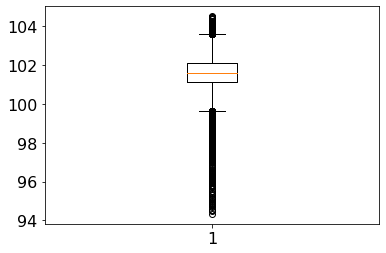

In [12]:
#  create a boxplot

plt.boxplot(PS)

## III. The "Spread" in the Data

After, having taken a look at the basic summary statistics, let's move on the describing the "spread" in the data.

We quantify the "spread" using the variance or standard deviation.

In [13]:
#  Standard deviation of surface pressure (use the np.std() function)

sigma_h_PS = np.std(PS)
print(sigma_h_PS)

0.8142326584362438


Let's plot the time series of hourly surface pressure data again, **but this time adding the mean as a solid, horizonal line and adding the value of the standard deviation as text** (you will need to add the code for adding a textbox as in the courseware).

Also uncomment the label lines of code and add your own labels to the plot.

In [14]:
#  as we did in the courseware, we create the time dimension data in units of days for plotting
ps_index = (np.arange(0,np.size(PS),1))/24.0

Text(0.5, 1.0, 'UTSC Surface Pressure Observations (2015-2022)')

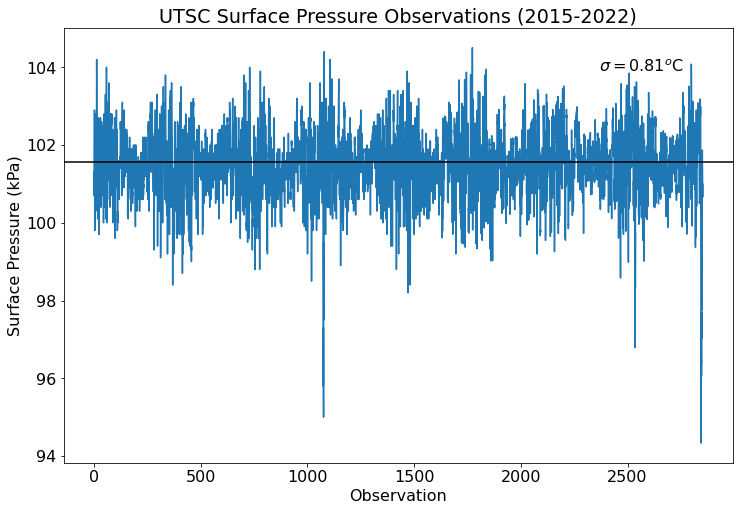

In [15]:
#  plot all data
fig = plt.figure(figsize=(12,8))

plt.plot(ps_index,PS)
plt.axhline(avg_PS,color='k')

#add textbox showing standard deviation here...
plt.text(0.8,0.9,r'$\sigma = $' + str(np.round(np.std(PS),2)) + r'$^o$C',  
         transform=plt.gca().transAxes, color = 'k')

plt.ylabel('Surface Pressure (kPa)')
plt.xlabel('Observation')
plt.title("UTSC Surface Pressure Observations (2015-2022)")

Let's test how robust our standard deviation is to the sampling frequency by sub-sampling the hourly data only once per month.

Compute the new standard deviation and then re-do the plot for the monthly sampled surface pressure.

Again, uncomment the label lines of code and add your own labels to the plot.

Text(0.5, 1.0, 'UTSC Surface Pressure Observations Sampled once-per-month (2015-2022)')

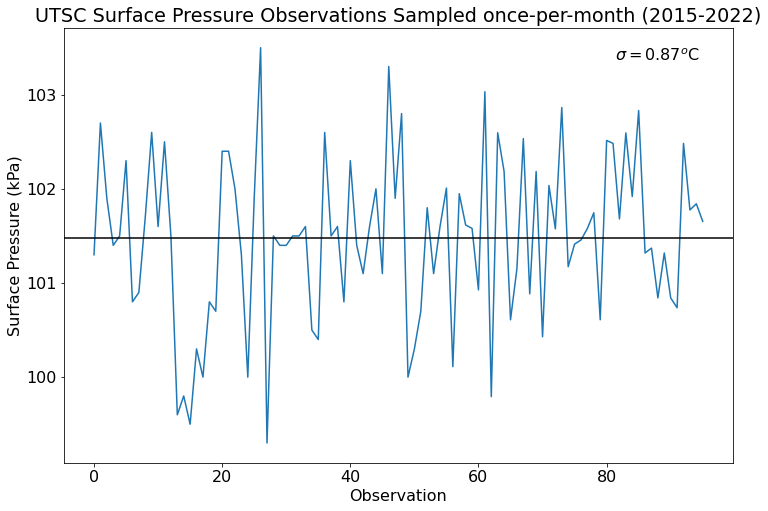

In [16]:
#plot only data sampled once-per-month
fig = plt.figure(figsize=(12,8))

plt.plot(PS[::720]) # use indexing to compute the monthly sampled surface pressure (see the variance example in the courseware)
plt.axhline(np.mean(PS[::720]),color='k') # use indexing to compute the monthly sampled surface pressure (see the variance example in the courseware)

#compute the new standard deviation here and add it to your plot in a textbox 
plt.text(0.95, 0.925,r'$\sigma = $' + str(np.round(np.std(PS[::720]),2)) + r'$^o$C', ha='right', 
         transform=plt.gca().transAxes, color = 'k')

plt.ylabel('Surface Pressure (kPa)')
plt.xlabel('Observation')
plt.title("UTSC Surface Pressure Observations Sampled once-per-month (2015-2022)")

## IV. The Shape of the Data

Finally, let's take a look at the shape of our surface pressure data. To do this, we will plot a histogram of the data.

Again, label the plot appropriately.

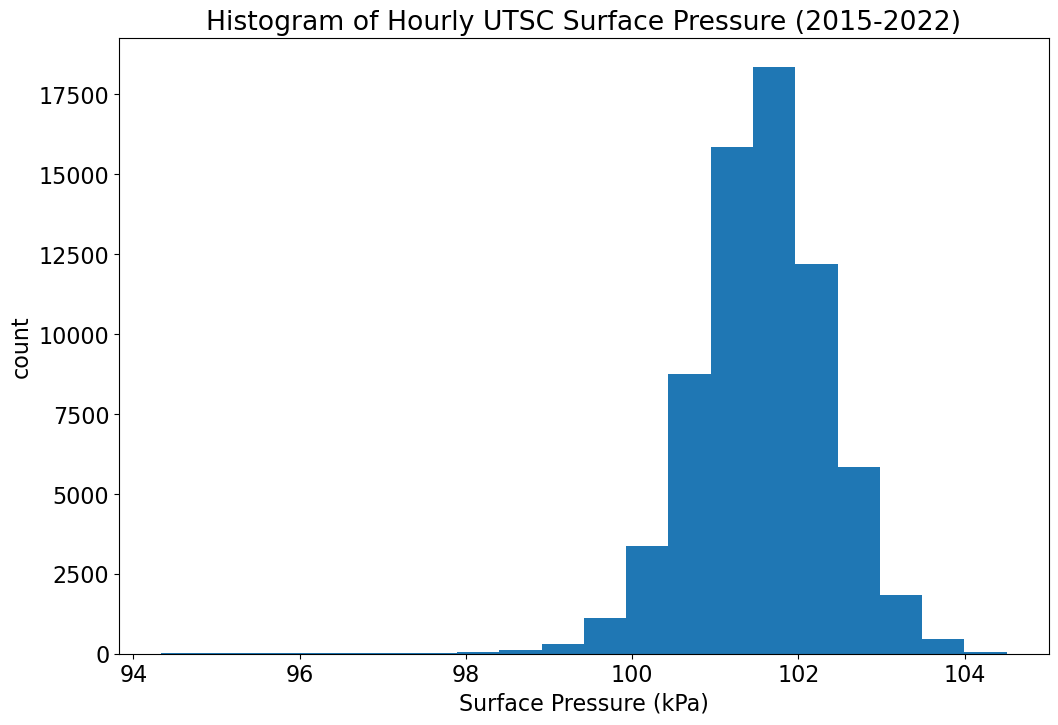

In [17]:
fig = plt.figure(figsize=(12,8))

#fill in the plotting line below
plt.hist(PS,bins=20)

plt.ylabel("count")
plt.xlabel("Surface Pressure (kPa)")
plt.title("Histogram of Hourly UTSC Surface Pressure (2015-2022)")

plt.savefig("hist.png")

Higher order summary statistics, such as the skewness and kurtosis, provide ways to quantify the shape of our data.

To compute these statistics, we need to import an additional package:

In [18]:
#  import scipy.stats package
import scipy.stats as stats

In [19]:
skew = stats.skew(PS)
kurt = stats.kurtosis(PS) # note scipy defines a kurtosis of zero for a gaussian distribution
print(skew,kurt)

-0.7155190044518722 4.178048306212326


## V. Empirical Rule

Now let's test the "empirical rule" of 68%. To do this we need to figure out how much of our data lies between -1 standard deviation and +1 standard deviation. 

In [20]:
#  Here we are extracting data from PS (using square brackets) under certain conditions (within the parentheses)
values_wi_1std = PS[(PS > (avg_PS - sigma_h_PS)) & (PS < (avg_PS + sigma_h_PS))]
print(values_wi_1std)

[101.3    101.3    101.3    ... 100.8432 100.9213 100.995 ]


We now have a list of values for surface pressure that fall within +/- 1 standard deviation of the mean. What percentage of the data is this?

To calculate this we use the 'len' function that tells the the length of our data, aka the number of elements we have in a given 1-dimensional variable.

In [21]:
# compute the percentage of values and print.
percentage_wi_1std = (len(values_wi_1std)/len(PS))*100
print(percentage_wi_1std)

71.62264812434265


### Variation on the 95% Rule: 

Using similar notation as above, find out the percentage of surface pressure values that are lower than 2 standard deviations below the mean.

In [22]:
values_below_2std = PS[(PS < (avg_PS - 2*sigma_h_PS))]

Now compute the percentage of values below 2 standard deviations, as we did above

In [23]:
# compute the percentage of values and print.
percentage_wi_2std = (len(values_below_2std)/len(PS))*100
print(percentage_wi_2std)

2.518405983405399
